##**Aim: To study and implement various morphological Operations**


Button(description='Generate New Image', style=ButtonStyle())

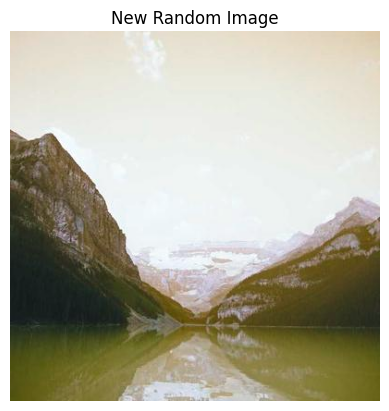

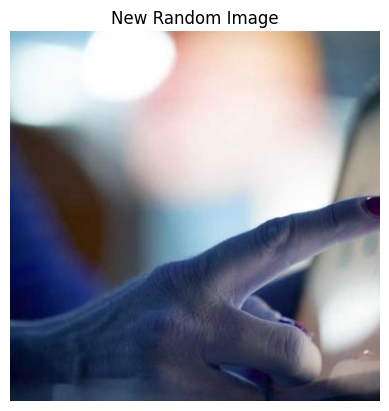

In [ ]:
# Topic: Setup, Image Loading, and UI for Random Image Generation
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from ipywidgets import interact, IntSlider, Dropdown, Button

# Function to fetch a random image from the internet
def get_random_image():
    url = "https://picsum.photos/400/400"
    response = requests.get(url)
    image_data = BytesIO(response.content)
    pil_image = Image.open(image_data)
    # Convert PIL image to OpenCV format (numpy array, BGR)
    return cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

def new_image():
    global image, gray, binary
    image = get_random_image()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

    plt.imshow(image)
    plt.title("New Random Image")
    plt.axis("off")

button = Button(description="Generate New Image")
button.on_click(lambda x: new_image())
button

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

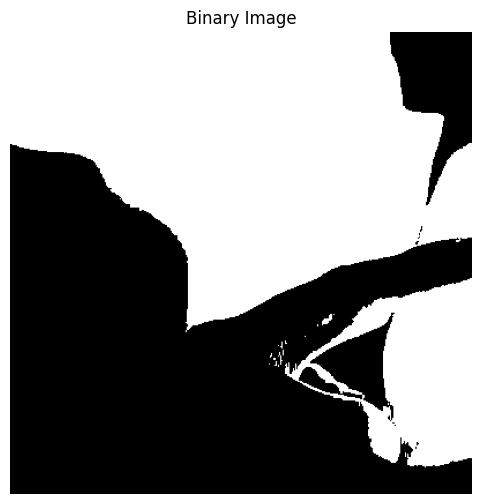

In [ ]:
# Topic: Image Preprocessing: Convert to Binary
# CONVERT TO BINARY

# Step 1: Convert color image (BGR) to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 2: Apply thresholding to create a binary image
# Pixels with value < 120 become black (0), others become white (255)
_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# Step 3: Visualize the binary image
plt.figure(figsize=(6,6))
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis("off")

In [ ]:
# Topic: Helper Function: Kernel Generation (Superseded by u-uvPgDAIQu7)
def get_kernel(shape, size):
    if shape == "Square":
        kernel = np.ones((size, size), np.uint8)

    elif shape == "Cross":
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))

    elif shape == "Ellipse":
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))

    return kernel

In [ ]:
# Topic: Helper Function: Morphological Operations (Superseded by _6sqLjHsIPC0 and ZIBye--zIYs7)
def morphology(operation, kernel_size, kernel_shape):
    # 1. Generate the kernel (structuring element)
    kernel = get_kernel(kernel_shape, kernel_size)

    # 2. Perform the selected operation on the 'binary' image
    # Note: 'binary' must be defined outside this function or passed as an argument
    if operation == "Erosion":
        result = cv2.erode(binary, kernel)

    elif operation == "Dilation":
        result = cv2.dilate(binary, kernel)

    elif operation == "Opening":
        result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    elif operation == "Closing":
        result = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    elif operation == "Gradient":
        result = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

    # Additional common operations often found in this logic:
    elif operation == "Top Hat":
        result = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT, kernel)

    elif operation == "Black Hat":
        result = cv2.morphologyEx(binary, cv2.MORPH_BLACKHAT, kernel)

    return result

In [ ]:
# Topic: Interactive Morphological Operations (Superseded by ZIBye--zIYs7 and IeqzvUt1IbXT)
def morphology(operation, kernel_size, kernel_shape):

    kernel = get_kernel(kernel_shape, kernel_size)

    if operation == "Erosion":
        result = cv2.erode(binary, kernel)

    elif operation == "Dilation":
        result = cv2.dilate(binary, kernel)

    elif operation == "Opening":
        result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    elif operation == "Closing":
        result = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    elif operation == "Gradient":
        result = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

    else:
        raise ValueError("Invalid operation. Choose from 'Erosion', 'Dilation', 'Opening', 'Closing', or 'Gradient'.")

    plt.figure(figsize=(6,6))
    plt.imshow(result, cmap='gray')
    plt.title(f"{operation} with {kernel_shape} kernel (size {kernel_size})")
    plt.axis("off")
    plt.show()

interact(morphology,
         operation=Dropdown(options=['Erosion', 'Dilation', 'Opening', 'Closing', 'Gradient'], description='Operation:'),
         kernel_size=IntSlider(min=1, max=15, step=2, value=3, description='Kernel Size:'),
         kernel_shape=Dropdown(options=['Square', 'Cross', 'Ellipse'], description='Kernel Shape:'))

interactive(children=(Dropdown(description='Operation:', options=('Erosion', 'Dilation', 'Opening', 'Closing',…

<function __main__.morphology(operation, kernel_size, kernel_shape)>

In [ ]:
# Topic: Helper Function: Kernel Generation
def get_kernel(shape, size):

    if shape == "Square":
      kernel = np.ones((size,size), np.uint8)

    elif shape == "Cross":
      kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))

    elif shape == "Ellipse":
      kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))

    else:
        raise ValueError("Invalid shape. Choose from 'Square', 'Cross', or 'Ellipse'.")

    return kernel

In [ ]:
# Topic: Interactive Morphological Operations
def morphology(operation, kernel_size, kernel_shape):

    kernel = get_kernel(kernel_shape, kernel_size)

    if operation == "Erosion":
        result = cv2.erode(binary, kernel)

    elif operation == "Dilation":
        result = cv2.dilate(binary, kernel)

    elif operation == "Opening":
        result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    elif operation == "Closing":
        result = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    elif operation == "Gradient":
        result = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

    elif operation == "Top Hat":
        result = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT, kernel)

    elif operation == "Black Hat":
        result = cv2.morphologyEx(binary, cv2.MORPH_BLACKHAT, kernel)

    else:
        raise ValueError("Invalid operation. Choose from 'Erosion', 'Dilation', 'Opening', 'Closing', or 'Gradient'.")

    plt.figure(figsize=(6,6))
    plt.imshow(result, cmap='gray')
    plt.title(f"{operation} with {kernel_shape} kernel (size {kernel_size})")
    plt.axis("off")
    plt.show()

interact(morphology,
         operation=Dropdown(options=['Erosion', 'Dilation', 'Opening', 'Closing', 'Gradient'], description='Operation:'),
         kernel_size=IntSlider(min=1, max=15, step=2, value=3, description='Kernel Size:'),
         kernel_shape=Dropdown(options=['Square', 'Cross', 'Ellipse'], description='Kernel Shape:'))

interactive(children=(Dropdown(description='Operation:', options=('Erosion', 'Dilation', 'Opening', 'Closing',…

<function __main__.morphology(operation, kernel_size, kernel_shape)>

In [ ]:
# Topic: Interactive Morphological Operations (Expanded)
interact(
    morphology,
    operation=Dropdown(options=[
        "Erosion",
        "Dilation",
        "Opening",
        "Closing",
        "Gradient",
        "Top Hat",
        "Black Hat"
    ]),
    kernel_size=IntSlider(min=1, max=15, step=2, value=3),
    kernel_shape=Dropdown(options=[
        "Square",
        "Cross",
        "Ellipse"
    ])
)

interactive(children=(Dropdown(description='operation', options=('Erosion', 'Dilation', 'Opening', 'Closing', …

<function __main__.morphology(operation, kernel_size, kernel_shape)>